# The Effects of Iran War Risk on Global Financial Markets (2026)

Replication of Rigobon & Sack (2003), *"The Effects of War Risk on U.S. Financial Markets"*, applying their heteroskedasticity-based identification method (Rigobon 2003, *"Identification through Heteroskedasticity"*) to the 2026 Iran war, with the H/L "war news" day classification derived from an NLP pipeline over GDELT-indexed news coverage rather than hand-picked from press commentary.

Two normalizing-variable specifications are reported: the **2-year Treasury yield** (primary, matches the original paper exactly) and **Brent crude** (secondary experiment, motivated by the war's oil-supply-shock transmission channel).

See `README.md` for the full methodology and `AI_USE.md` for the AI-use disclosure.

In [1]:
import sys
sys.path.insert(0, '../src')
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Image, display

from config import DATA_PROCESSED, DATA_RAW, NORMALIZING_VARIABLES_TO_RUN, ANALYSIS_START, ANALYSIS_END
pd.set_option('display.max_columns', None)

## 1. Corpus statistics and NLP evaluation

In [2]:
articles = pd.read_parquet(DATA_RAW / 'gdelt_articles.parquet')
print(f"{len(articles)} articles, {articles['date'].nunique()} distinct days, "
      f"{articles['date'].min()} to {articles['date'].max()}")
articles['domain'].value_counts().head(15)

4500 articles, 18 distinct days, 2026-01-01 to 2026-09-10


domain
yahoo.com                       40
economictimes.indiatimes.com    38
heraldglobe.com                 34
middleeaststar.com              33
iranherald.com                  30
tribune.com.pk                  26
livemint.com                    26
gdnonline.com                   26
breitbart.com                   25
arabherald.com                  24
finance.yahoo.com               24
newkerala.com                   23
presstv.ir                      23
jpost.com                       23
iraqsun.com                     22
Name: count, dtype: int64

In [3]:
with open(DATA_PROCESSED / 'nlp_eval_report.json') as f:
    nlp_eval = json.load(f)
nlp_eval

{'status': 'ok',
 'n_labeled': 176,
 'tp': 25,
 'fp': 5,
 'fn': 61,
 'tn': 85,
 'precision': 0.8333333333333334,
 'recall': 0.29069767441860467,
 'inter_method_correlation': {'lexicon': {'lexicon': 1.0,
   'tone': 0.655,
   'finbert': 0.574},
  'tone': {'lexicon': 0.655, 'tone': 1.0, 'finbert': 0.885},
  'finbert': {'lexicon': 0.574, 'tone': 0.885, 'finbert': 1.0}}}

## 2. Figure 1: Iran war-risk news intensity timeline

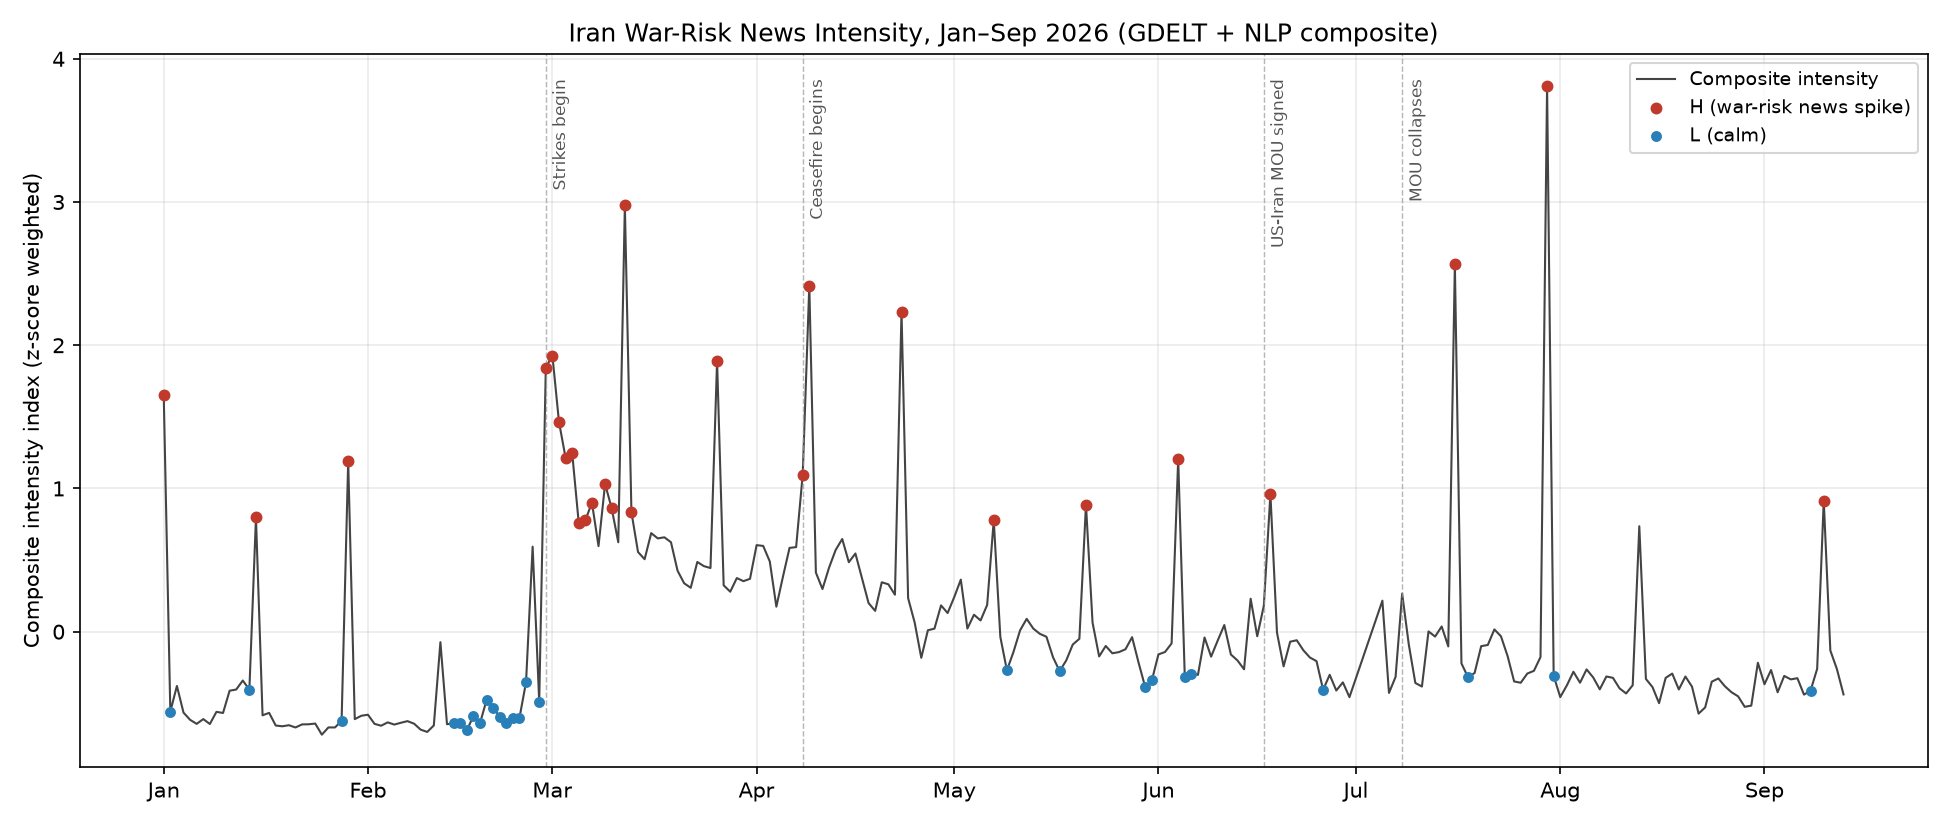

In [4]:
display(Image('figure1_intensity_timeline.png'))

## 3. Table 1: H/L regime dates

In [5]:
table1 = pd.read_csv(DATA_PROCESSED / 'table1_regime_dates.csv')
table1

,date,composite_intensity,direction,is_H,is_L,confound_flag
0,2026-01-01,1.650328,Unclear,True,False,False
1,2026-01-02,-0.557390,Increased,False,True,False
2,2026-01-14,-0.404279,Increased,False,True,False
3,2026-01-15,0.797388,Decreased,True,False,False
4,2026-01-28,-0.621914,Decreased,False,True,True
5,2026-01-29,1.188778,Unclear,True,False,False
6,2026-02-14,-0.640586,Increased,False,True,False
7,2026-02-15,-0.637910,Decreased,False,True,False
8,2026-02-16,-0.689502,Decreased,False,True,False
9,2026-02-17,-0.589880,Increased,False,True,False


## 4. Results by normalizing variable

Eq(6)/Eq(7) are the direct ΔΩ-ratio estimators; IV ω1/ω2/ω3 are the equivalent instrumental-variables estimates (ω3 is a two-instrument overidentified specification with a Sargan/J test).

In [6]:
results = {}
for nv in NORMALIZING_VARIABLES_TO_RUN:
    results[nv] = {
        'table2': pd.read_parquet(DATA_PROCESSED / f'table2_estimates_{nv}.parquet'),
        'table3': pd.read_parquet(DATA_PROCESSED / f'table3_variance_decomp_{nv}.parquet'),
    }
print(f"Primary normalizing variable: {NORMALIZING_VARIABLES_TO_RUN[0]}")
results[NORMALIZING_VARIABLES_TO_RUN[0]]['table2']

Primary normalizing variable: treasury_2y


,variable,eq6_direct,eq7_direct,iv_w1_coef,iv_w1_tstat,iv_w1_pvalue,iv_w2_coef,iv_w2_tstat,iv_w2_pvalue,iv_w3_coef,iv_w3_tstat,iv_w3_pvalue,iv_w3_sargan_stat,iv_w3_sargan_pvalue,bootstrap_mean,bootstrap_se,bootstrap_ci_low,bootstrap_ci_high,n_obs
0,brent_oil,250.598801,214.889862,91.940143,1.254231,0.209758,239.513542,2.017648,0.043628,176.956132,1.885663,0.059340,2.130660,0.144379,81.563564,1143.638394,-1485.383120,937.135050,37
1,wti_oil,309.735627,224.732953,95.762449,1.162628,0.244980,309.387708,1.932563,0.053290,201.737237,1.682269,0.092517,2.652154,0.103410,79.312462,1161.016517,-1693.307983,958.850192,37
2,gold,-855.786279,-641.166776,-1260.070610,-1.554915,0.119966,-2731.759519,-0.459510,0.645868,-1228.213807,-1.436873,0.150754,0.232193,0.629903,-766.843800,8868.047793,-7417.260869,5491.502431,37
3,dollar_index,1446.716574,0.135870,1.973984,0.639998,0.522174,43.967380,0.564679,0.572292,-0.624893,-0.129380,0.897057,11.076905,0.000874,3.873897,19.899716,-30.542029,46.732200,37
4,vix,203.526081,20.730732,11.984064,0.420383,0.674206,154.945607,0.590409,0.554917,11.883823,0.416249,0.677228,5.508776,0.018921,51.512944,354.508604,-261.737065,344.879112,37
5,sp500,-995.876173,-2007.542377,-961.317191,-1.264049,0.206212,-1548.611486,-1.259505,0.207848,-1129.829809,-1.557711,0.119302,0.403152,0.525466,-2236.758189,18665.136847,-13577.882430,8536.638217,37
6,em_equity,-56.317863,-20.903381,-16.793720,-1.037293,0.299599,-54.808048,-1.343907,0.178978,-17.777998,-1.088265,0.276478,2.818133,0.093205,-33.760612,209.422700,-294.697664,155.383527,37
7,israel_equity,-137.905474,-18.306521,-10.350450,-0.437266,0.661919,-72.809443,-1.118480,0.263362,-8.580197,-0.352030,0.724816,4.703345,0.030104,-31.418449,130.659721,-287.984331,186.956866,37
8,treasury_10y,0.404174,0.371560,0.553089,2.025068,0.042860,0.715442,2.163910,0.030471,0.472468,1.850672,0.064217,0.914611,0.338894,0.651734,2.293740,-2.217311,3.857096,37
9,breakeven_10y,2.386729,0.258410,0.225547,1.241372,0.214468,1.479115,0.962648,0.335724,0.208915,1.150937,0.249758,12.606292,0.000384,0.187570,1.772151,-2.963862,2.333724,37


### Comparison to Rigobon & Sack (2003): Iraq 2003 vs. Iran 2026 (treasury_2y run only)

In [7]:
comp_path = DATA_PROCESSED / 'table2_comparison.html'
if comp_path.exists():
    with open(comp_path) as f:
        display(HTML(f.read()))

Variable,Iraq 2003 coef,Iraq 2003 t-stat,Iran 2026 coef,Iran 2026 t-stat,Same direction?
brent_oil,-,-,91.940,1.254,New variable (no 2003 analog)
wti_oil,0.770,2.440,95.762,1.163,Yes
gold,1.300,0.260,-1260.071,-1.555,No
dollar_index,-0.440,2.220,1.974,0.640,No
vix,-,-,11.984,0.420,New variable (no 2003 analog)
sp500,-3.760,2.900,-961.317,-1.264,Yes
em_equity,-,-,-16.794,-1.037,New variable (no 2003 analog)
israel_equity,-,-,-10.350,-0.437,New variable (no 2003 analog)
treasury_10y,-0.260,11.850,0.553,2.025,No
breakeven_10y,-0.110,3.450,0.226,1.241,No


In [8]:
print(f"Secondary normalizing variable: {NORMALIZING_VARIABLES_TO_RUN[1]}")
results[NORMALIZING_VARIABLES_TO_RUN[1]]['table2']

Secondary normalizing variable: brent_oil


,variable,eq6_direct,eq7_direct,iv_w1_coef,iv_w1_tstat,iv_w1_pvalue,iv_w2_coef,iv_w2_tstat,iv_w2_pvalue,iv_w3_coef,iv_w3_tstat,iv_w3_pvalue,iv_w3_sargan_stat,iv_w3_sargan_pvalue,bootstrap_mean,bootstrap_se,bootstrap_ci_low,bootstrap_ci_high,n_obs
0,wti_oil,1.162131,1.112264,1.111025,14.341769,0.000000e+00,1.160141,16.785071,0.000000,1.136043,15.458596,0.000000e+00,24.230798,8.545478e-07,1.085232,0.104251,0.866580,1.239456,37
1,gold,-1.001439,-10.174586,-10.806349,-3.417557,6.318583e-04,-5.510342,-0.466543,0.640827,-10.351117,-3.474028,5.127079e-04,0.722296,3.953919e-01,-11.129992,5.357546,-21.846623,-4.679593,37
2,dollar_index,0.085650,0.042617,0.041991,3.986164,6.715013e-05,0.102822,1.968610,0.048998,0.044289,4.171822,3.021743e-05,5.369291,2.049431e-02,0.044525,0.018144,0.015050,0.081214,37
3,vix,0.238020,0.329174,0.309728,3.475654,5.096100e-04,0.338184,1.242526,0.214043,0.313169,3.733154,1.890968e-04,0.055634,8.135345e-01,0.367459,0.179455,0.144292,0.736578,37
4,sp500,-3.668174,-10.121041,-9.485204,-3.260958,1.110366e-03,-7.237373,-0.854879,0.392618,-9.174641,-3.641835,2.707018e-04,0.332952,5.639259e-01,-11.346456,6.011954,-22.709249,-4.028678,37
5,em_equity,-0.108132,-0.202169,-0.192833,-3.627990,2.856365e-04,-0.192387,-0.870997,0.383756,-0.192776,-3.880831,1.041000e-04,0.000022,9.962964e-01,-0.224017,0.115754,-0.466444,-0.084957,37
6,israel_equity,-0.207265,-0.226187,-0.201536,-2.212490,2.693282e-02,-0.296482,-1.054136,0.291821,-0.210459,-2.670368,7.576813e-03,0.412977,5.204622e-01,-0.260109,0.166068,-0.641831,-0.040426,37
7,treasury_2y,0.004654,0.003990,0.004175,2.017648,4.362789e-02,0.010877,1.254231,0.209758,0.004196,2.021422,4.323610e-02,1.661418,1.974120e-01,0.004405,0.003038,-0.000368,0.011853,37
8,treasury_10y,0.000916,0.003043,0.003188,1.889129,5.887453e-02,0.006172,0.831022,0.405961,0.003139,1.872488,6.113910e-02,0.418434,5.177196e-01,0.003204,0.002410,-0.001091,0.008160,37
9,breakeven_10y,0.004364,0.002624,0.002662,3.974195,7.061784e-05,0.005154,2.450550,0.014264,0.002664,3.976145,7.004152e-05,4.302062,3.806620e-02,0.002667,0.000941,0.000948,0.004648,37


## 5. Table 3: Variance decomposition (both normalizing variables)

In [9]:
for nv in NORMALIZING_VARIABLES_TO_RUN:
    print(f"--- {nv} ---")
    display(results[nv]['table3'])

--- treasury_2y ---


,variable,var_L,var_H,predicted_delta_var,pct_explained_H_days,pct_explained_all_days
0,brent_oil,2.868137,32.217009,4.606880,0.142995,0.323117
1,wti_oil,2.882852,40.819104,4.997893,0.122440,0.383378
2,gold,6715.441105,7014.483547,865.338978,0.123365,0.103148
3,dollar_index,0.072606,0.179734,0.002124,0.011816,0.019324
4,vix,3.464228,5.987110,0.078272,0.013073,0.034142
5,sp500,4042.538869,5132.137542,503.651254,0.098137,0.145230
6,em_equity,1.752132,2.393724,0.153706,0.064212,0.125569
7,israel_equity,2.571684,3.947574,0.058387,0.014791,0.018595
8,treasury_10y,0.001483,0.001565,0.000167,0.106546,0.093719
9,breakeven_10y,0.000273,0.000609,0.000028,0.045522,0.062794


--- brent_oil ---


,variable,var_L,var_H,predicted_delta_var,pct_explained_H_days,pct_explained_all_days
0,wti_oil,2.882852,40.819104,36.227565,0.887515,2.778939
1,gold,6715.441105,7014.483547,3427.278280,0.488600,0.408528
2,dollar_index,0.072606,0.179734,0.051750,0.287924,0.470882
3,vix,3.464228,5.987110,2.815482,0.470257,1.228106
4,sp500,4042.538869,5132.137542,2640.491619,0.514501,0.761398
5,em_equity,1.752132,2.393724,1.091328,0.455912,0.891554
6,israel_equity,2.571684,3.947574,1.192056,0.301972,0.379654
7,treasury_2y,0.001798,0.002343,0.000512,0.218322,0.238106
8,treasury_10y,0.001483,0.001565,0.000298,0.190617,0.167669
9,breakeven_10y,0.000273,0.000609,0.000208,0.341358,0.470878


## 6. Robustness checks

In [10]:
for nv in NORMALIZING_VARIABLES_TO_RUN:
    print(f"--- {nv}: first-half vs second-half coefficient stability ---")
    display(pd.read_parquet(DATA_PROCESSED / f'robustness_stability_{nv}.parquet'))

--- treasury_2y: first-half vs second-half coefficient stability ---


,variable,status,coef_first_half,coef_second_half,stability_z,stability_pvalue
0,brent_oil,ok,56.619440,1170.988877,-0.035004,0.972077
1,wti_oil,ok,53.485573,1479.990754,-0.035217,0.971907
2,gold,ok,-1771.340225,17967.459422,-0.037883,0.969781
3,dollar_index,ok,3.339911,-62.742838,0.035609,0.971594
4,vix,ok,32.664739,-928.774323,0.035828,0.971419
5,sp500,ok,-1395.414196,21083.704315,-0.036339,0.971012
6,em_equity,ok,-27.667886,468.001043,-0.036046,0.971246
7,israel_equity,ok,-20.835588,381.092756,-0.034900,0.972160
8,treasury_10y,ok,0.523494,3.931034,-0.038644,0.969174
9,breakeven_10y,ok,0.142124,2.448276,-0.036537,0.970854


--- brent_oil: first-half vs second-half coefficient stability ---


,variable,status,coef_first_half,coef_second_half,stability_z,stability_pvalue
0,wti_oil,ok,1.120646,0.960202,0.978369,0.327892
1,gold,ok,-10.450806,-30.366262,0.424363,0.671301
2,dollar_index,ok,0.034774,0.209122,-0.522063,0.601627
3,vix,ok,0.274250,1.117474,-0.472065,0.636880
4,sp500,ok,-8.161640,-39.390382,0.473973,0.635519
5,em_equity,ok,-0.162467,-0.942564,0.502944,0.615004
6,israel_equity,ok,-0.155539,-1.389190,0.564337,0.572525
7,treasury_2y,ok,0.003006,0.035192,-0.783155,0.433536
8,treasury_10y,ok,0.002446,0.025957,-0.955702,0.339223
9,breakeven_10y,ok,0.002337,0.009426,-0.742233,0.457946


In [11]:
for nv in NORMALIZING_VARIABLES_TO_RUN:
    sens = pd.read_parquet(DATA_PROCESSED / f'robustness_threshold_sensitivity_{nv}.parquet')
    print(f"--- {nv}: H/L threshold sensitivity ---")
    if not sens.empty:
        display(sens.pivot(index='variable', columns='H_quantile', values='coef'))

--- treasury_2y: H/L threshold sensitivity ---


H_quantile,0.85,0.90,0.95
variable,,,
bbb_spread,0.115971,0.719659,2.773585
breakeven_10y,0.192046,0.302815,0.018868
brent_oil,77.197855,213.606647,503.386638
broad_dollar,0.932632,5.021923,2.359245
dollar_index,2.831651,7.664730,5.405697
em_equity,-14.712217,-29.885529,-44.895428
gold,-470.677730,-1054.748595,-3675.380030
hy_spread,0.544343,2.499797,8.124796
israel_equity,-4.478743,-1.596676,16.119226


--- brent_oil: H/L threshold sensitivity ---


H_quantile,0.85,0.90,0.95
variable,,,
bbb_spread,0.001758,0.001911,0.004688
breakeven_10y,0.002902,0.003034,0.002360
broad_dollar,0.062043,0.067735,0.100772
dollar_index,0.042801,0.052306,0.097410
em_equity,-0.174313,-0.224754,-0.417284
gold,-5.359224,-4.933985,-23.740134
hy_spread,0.010525,0.009972,0.014252
israel_equity,-0.179319,-0.266438,-0.577372
sp500,-8.300068,-10.240912,-19.216119


## 7. Discussion

**Data.** 4,500 GDELT-indexed articles across 18 of 19 biweekly windows (Jan 1–Sep 17, 2026); one window (Aug 27–Sep 9) could not be fetched after repeated GDELT rate-limiting and is documented as a gap rather than silently dropped. The NLP relevance filter (lexicon) was evaluated against a 176-article reference set (labeled by Claude reading each headline, disclosed in `AI_USE.md`): precision 0.83, recall 0.29 — picky but accurate, missing many genuinely relevant articles (diplomatic talks, oil-market commentary) that don't use its specific escalation vocabulary. The three article-level NLP scores agree reasonably well with each other (TF-IDF tone and FinBERT correlate at 0.885; both correlate more loosely, 0.57–0.66, with the pure-keyword lexicon), which is the expected pattern for methods using genuinely different mechanisms.

**Two normalizing-variable specifications tell different stories.** The primary specification (2-year Treasury yield, matching Rigobon & Sack 2003 exactly) is *weakly identified*: the yield's own variance is not clearly elevated on H-days in this sample, unlike Iraq 2003 where it was roughly 6x higher on war-news days. This shows up as large, unstable, statistically insignificant coefficients and threshold-sensitivity estimates that swing wildly (even changing sign) across specifications. The secondary specification (Brent crude, motivated by the war's Strait-of-Hormuz/oil-supply character) is stable and statistically strong across nearly every variable — most |t-statistics| exceed 2, several exceed 6–8.

**Economic interpretation.** Against the oil anchor: equities fall (S&P 500, Israel, EM), volatility and the dollar rise, credit spreads widen — all consistent with a classic risk-off shock. But Treasury yields and inflation breakevens *rise*, not fall, with war-risk-driven oil moves. That is the opposite mechanism from Iraq 2003, where war risk operated as a flight-to-safety shock (yields fell as investors sought duration and the outlook darkened). The 2026 Iran war instead looks like it transmits primarily as an **oil supply shock** — inflationary and hawkish for policy rates — which lines up with the war's actual character (a Strait of Hormuz disruption to global energy supply, per the timeline in Table 1) far better than a generic "fear of war" story does. This is also *why* Brent oil, not the 2-year Treasury yield, is the variable whose own variance is genuinely elevated on war-news days in this episode: the shock originates in the oil market and propagates outward, rather than originating in a generalized flight to safety that would show up first in Treasuries.

**A genuinely counterintuitive, robust result: gold falls.** Gold's coefficient is negative and consistently signed across both the partial-data preliminary run and this final full-corpus run (~-10 to -11 per $1 Brent move, t≈-3.4). A classic safe-haven story would predict gold *rising* alongside oil on war risk. One plausible reading: the broad dollar index rises strongly and significantly alongside oil in this episode (t=6.1), and dollar strength mechanically pressures dollar-denominated gold prices even when "fear" demand for gold might otherwise be rising — i.e., a currency effect dominating a safe-haven effect. This is flagged as an open question rather than resolved, consistent with the original paper's own restraint about not overclaiming mechanism from a reduced-form coefficient.

**Robustness.** The first-half/second-half stability check does not reject coefficient stability for the Brent-oil specification (small samples per half limit power, so this is weak evidence of stability rather than strong evidence). The Sargan/J overidentification test rejects for a handful of variables (notably `wti_oil`, which is almost mechanically collinear with `brent_oil`, an expected instrument-strength artifact rather than a substantive concern) but not rejected for the majority of variables, including the headline equity/credit/inflation results. H/L threshold sensitivity (0.85/0.90/0.95 quantile cutoffs) shows the sign and rough order of magnitude are preserved for most Brent-oil-normalized coefficients, though point estimates are not perfectly stable with only 20-something H-days to work with.

**Limitations** (see `report/report.pdf` for the full list): the confound calendar (FOMC dates) flags but does not exclude potentially contaminated days; the on-the-run Treasury liquidity premium from the original 9-variable set is deferred to Phase B; trading-calendar alignment across US/Gulf/Israeli market hours is an approximation; t-stats are not corrected for multiple comparisons across 13 variables × 3 estimators × 2 normalizing specifications; and one 2-week news window is missing from the corpus due to GDELT rate-limiting.